# BigMart Sales Prediction

## Introduction

The goal of this project is to analyze the BigMart sales dataset and explore the factors that influence product sales across different outlets.

In this project, we will perform Exploratory Data Analysis (EDA), clean the data, and apply feature engineering techniques to prepare the dataset for machine learning.

The project will follow a complete data science workflow, starting from understanding and analyzing the data and ending with building a machine learning model to predict sales.

## Problem Definition

### Problem Statement

BigMart has information about different products and outlets, including product characteristics, outlet characteristics, and historical sales.

The objective is to build a machine learning model that can predict the sales of a particular product at a particular outlet.

### Objective

The main objective of this project is to predict:

**`Item_Outlet_Sales`**

based on the available product and outlet features.

### Machine Learning Task

This is a **Supervised Learning** problem because we have a target variable (`Item_Outlet_Sales`) with known values in the training data.

Since `Item_Outlet_Sales` is a continuous numerical value, this problem is a **Regression** problem.

## Dataset

The dataset used in this project is the **BigMart Sales Dataset**.

The dataset contains information about products and the outlets where they are sold.

### Dataset Features

The main features include:

- `Item_Identifier` — Unique identifier for each product.
- `Item_Weight` — Weight of the product.
- `Item_Fat_Content` — Fat content category of the product.
- `Item_Visibility` — Percentage of total display area allocated to the product.
- `Item_Type` — Category/type of the product.
- `Item_MRP` — Maximum Retail Price of the product.
- `Outlet_Identifier` — Unique identifier for each outlet.
- `Outlet_Establishment_Year` — Year in which the outlet was established.
- `Outlet_Size` — Size of the outlet.
- `Outlet_Location_Type` — Type of location where the outlet is located.
- `Outlet_Type` — Type of outlet.
- `Item_Outlet_Sales` — Sales of the product in the particular outlet. This is the **target variable**.

### Dataset Files

The dataset is provided in three main CSV files:

- `train.csv` — Contains the features and the target variable. This will be used for EDA, data cleaning, feature engineering, and model training.
- `test.csv` — Contains the features without the target variable. It will be used to generate final predictions.
- `sample_submission.csv` — Provides the required format for submitting predictions to Kaggle.

## Importing DataSet

In [1]:
# importing necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)#setting the random seed

In [2]:
df=pd.read_csv("DataSet/train.csv")


## EDA

In [3]:
print("Train dataset Shape:",df.shape)


Train dataset Shape: (8523, 12)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [6]:
# checking the categorical and continues
df.nunique()

Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

In [7]:
# Getting Outlets Info
df[["Outlet_Identifier","Outlet_Establishment_Year"
    ,"Outlet_Size","Outlet_Location_Type","Outlet_Type"]
    ].\
drop_duplicates().sort_values(by="Outlet_Establishment_Year").\
    reset_index().drop(["index"],axis=1)
        

,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,OUT027,1985,Medium,Tier 3,Supermarket Type3
1,OUT019,1985,Small,Tier 1,Grocery Store
2,OUT013,1987,High,Tier 3,Supermarket Type1
3,OUT046,1997,Small,Tier 1,Supermarket Type1
4,OUT010,1998,NaN,Tier 3,Grocery Store
5,OUT049,1999,Medium,Tier 1,Supermarket Type1
6,OUT045,2002,NaN,Tier 2,Supermarket Type1
7,OUT035,2004,Small,Tier 2,Supermarket Type1
8,OUT017,2007,NaN,Tier 2,Supermarket Type1
9,OUT018,2009,Medium,Tier 3,Supermarket Type2


In [8]:
# Add some Features to help us i EDA
df_new=df.copy()
df_new["Weight_Range"]=pd.cut(df["Item_Weight"],
                                 bins=[0,5,10,15,20,25],
                                 labels=["0-5","5-10","10-15","15-20","+20"])
df_new.Item_Fat_Content=df_new.Item_Fat_Content.map({"Low Fat":"LF","Regular":"Reg","reg":"Reg","low fat":"LF"})
df_new["Item_Quantity_Sold"]=round(df_new["Item_Outlet_Sales"]/df_new["Item_MRP"])
df_new["Visibility_Range"]=pd.cut(df_new["Item_Visibility"],
                                 bins=[0,0.05,0.1,0.15,0.2,0.25,0.3,0.35],
                                 labels=["0-5%","5-10%","10-15%","15-20%","20-25%","25-30%","+30%"])

In [9]:
df_new.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Quantity_Sold
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914,15.424850
std,4.643456,0.051598,62.275067,8.371760,1706.499616,9.190713
min,4.555000,0.000000,31.290000,1985.000000,33.290000,1.000000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400,9.000000
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000,15.000000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400,21.000000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800,57.000000


In [10]:
df_new.describe(include="object")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26436\4285481084.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_new.describe(include="object")


,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8207,8523,8523,6113,8523,8523
unique,1559,2,16,10,3,3,4
top,FDG33,LF,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5201,1232,935,2793,3350,5577


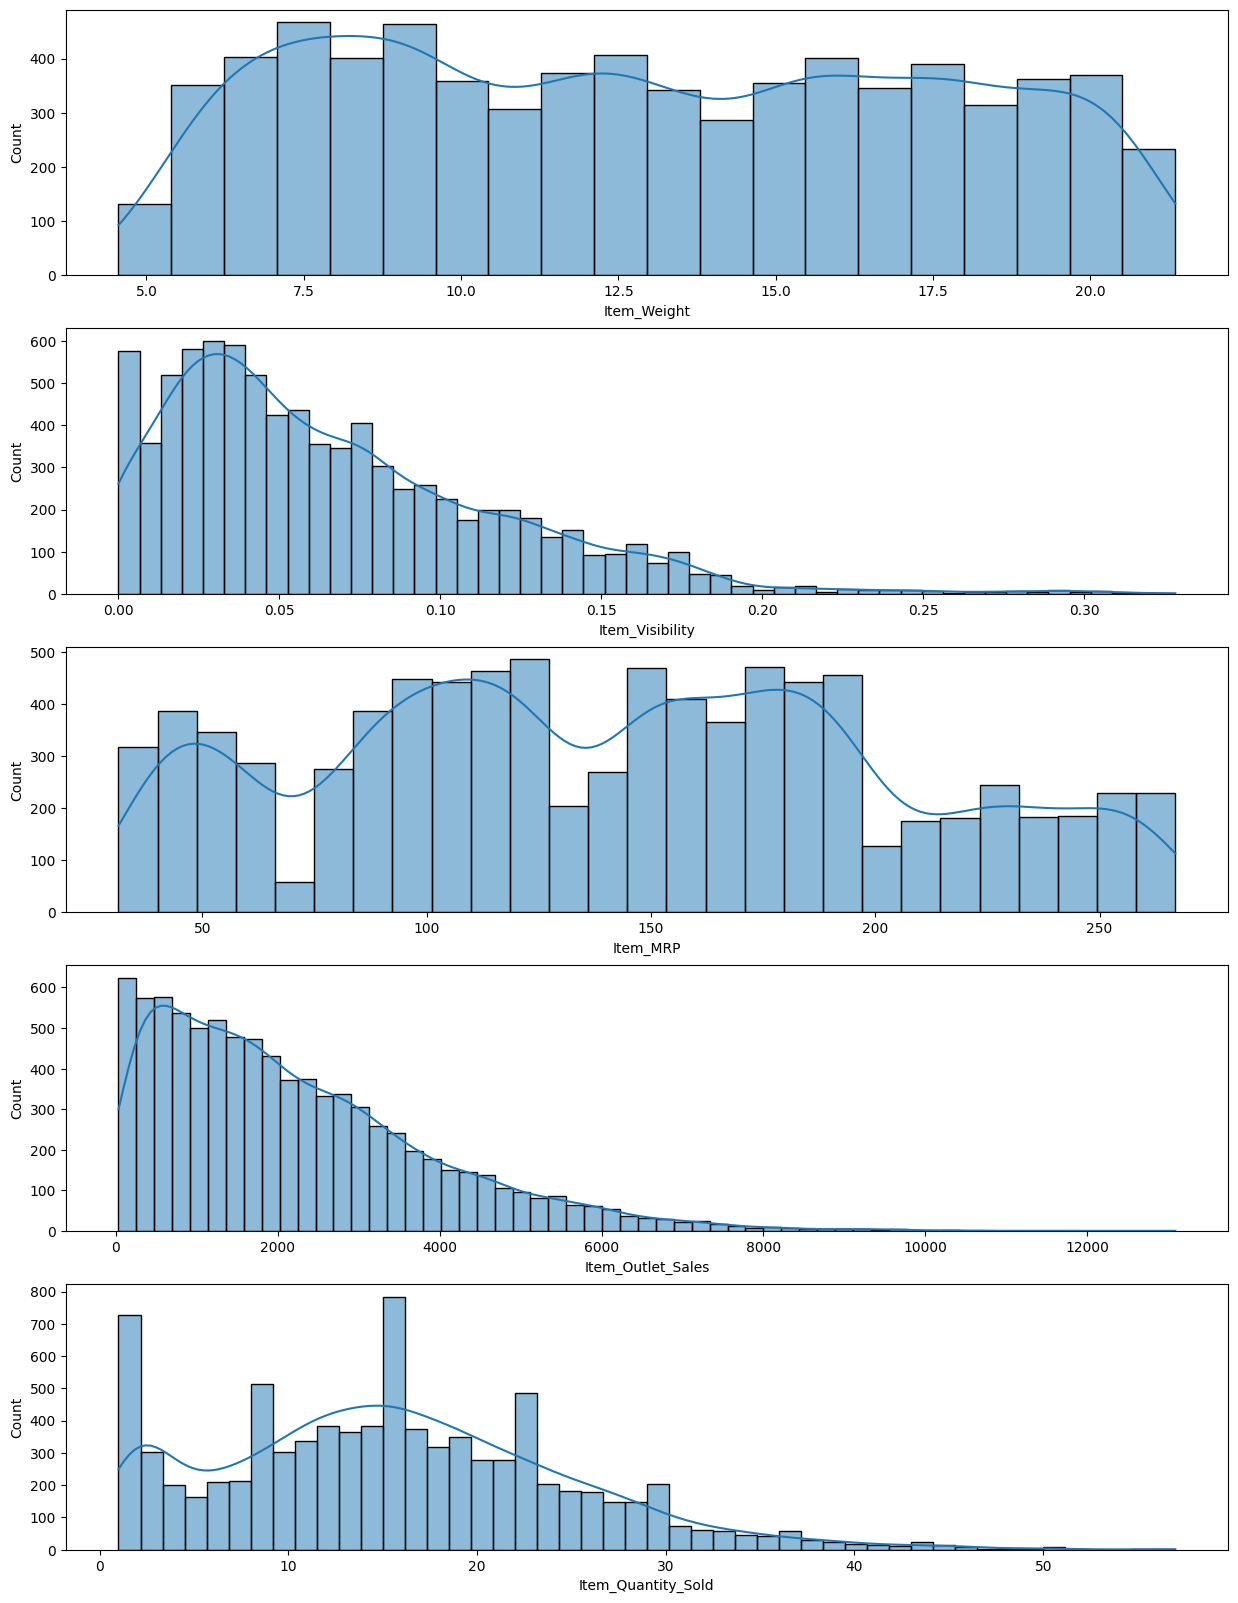

In [11]:
continues_cols=["Item_Weight","Item_Visibility","Item_MRP","Item_Outlet_Sales","Item_Quantity_Sold"]
fig,ax=plt.subplots(nrows=len(continues_cols),figsize=(15,20))
for i in range(len(continues_cols)):
    sns.histplot(data=df_new,x=continues_cols[i],kde=True,ax=ax[i])

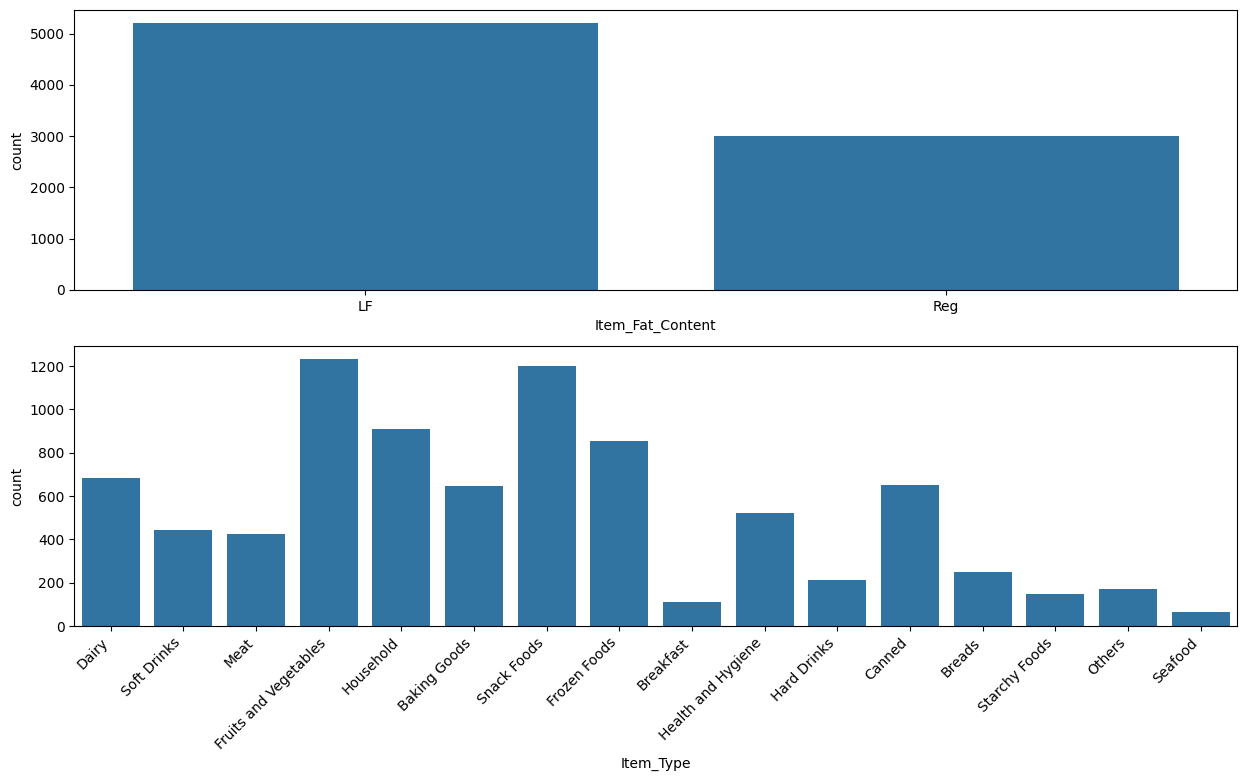

In [12]:
cat_cols=["Item_Fat_Content","Item_Type"]
fig,ax=plt.subplots(nrows=len(cat_cols),figsize=(15,8))
for i in range(len(cat_cols)):
    sns.countplot(data=df_new,x=cat_cols[i],ax=ax[i],)
plt.xticks(rotation=45, ha="right") 
plt.show()

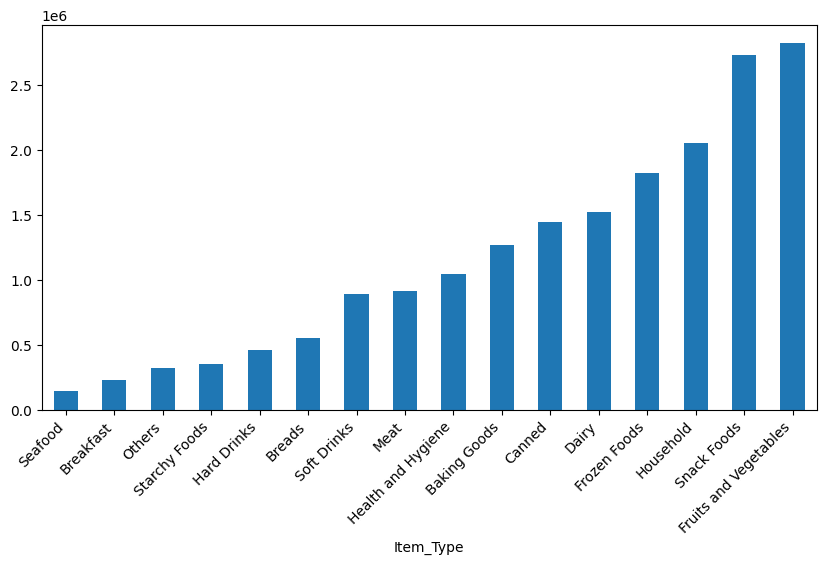

In [13]:
# see how much revenu does each product type give us
fig,ax=plt.subplots(figsize=(10,5))
ax=df.groupby("Item_Type").Item_Outlet_Sales.sum().sort_values().plot(kind="bar")
plt.xticks(rotation=45, ha="right")
plt.show()

In [14]:
outlets_total_sales=(df_new.groupby(["Outlet_Identifier","Item_Type"]).Item_Outlet_Sales.sum())

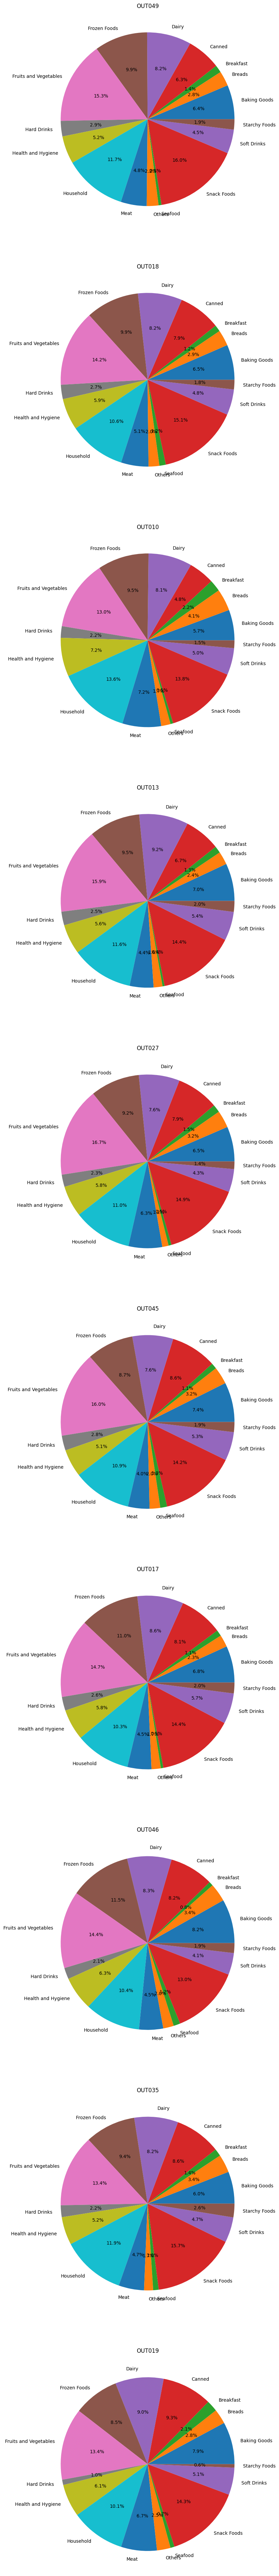

In [15]:
# See the sales income for each product type in each outlet
fig,axes=plt.subplots(nrows=10,ncols=1,figsize=(50,100))
axes=axes.flatten()
for i,outlet in enumerate(df_new.Outlet_Identifier.unique()):
    outlet_sales=outlets_total_sales[outlet]
    axes[i].pie(outlet_sales,labels=outlet_sales.index,autopct="%1.1f%%")
    axes[i].set_title(outlet)
     
plt.show()    

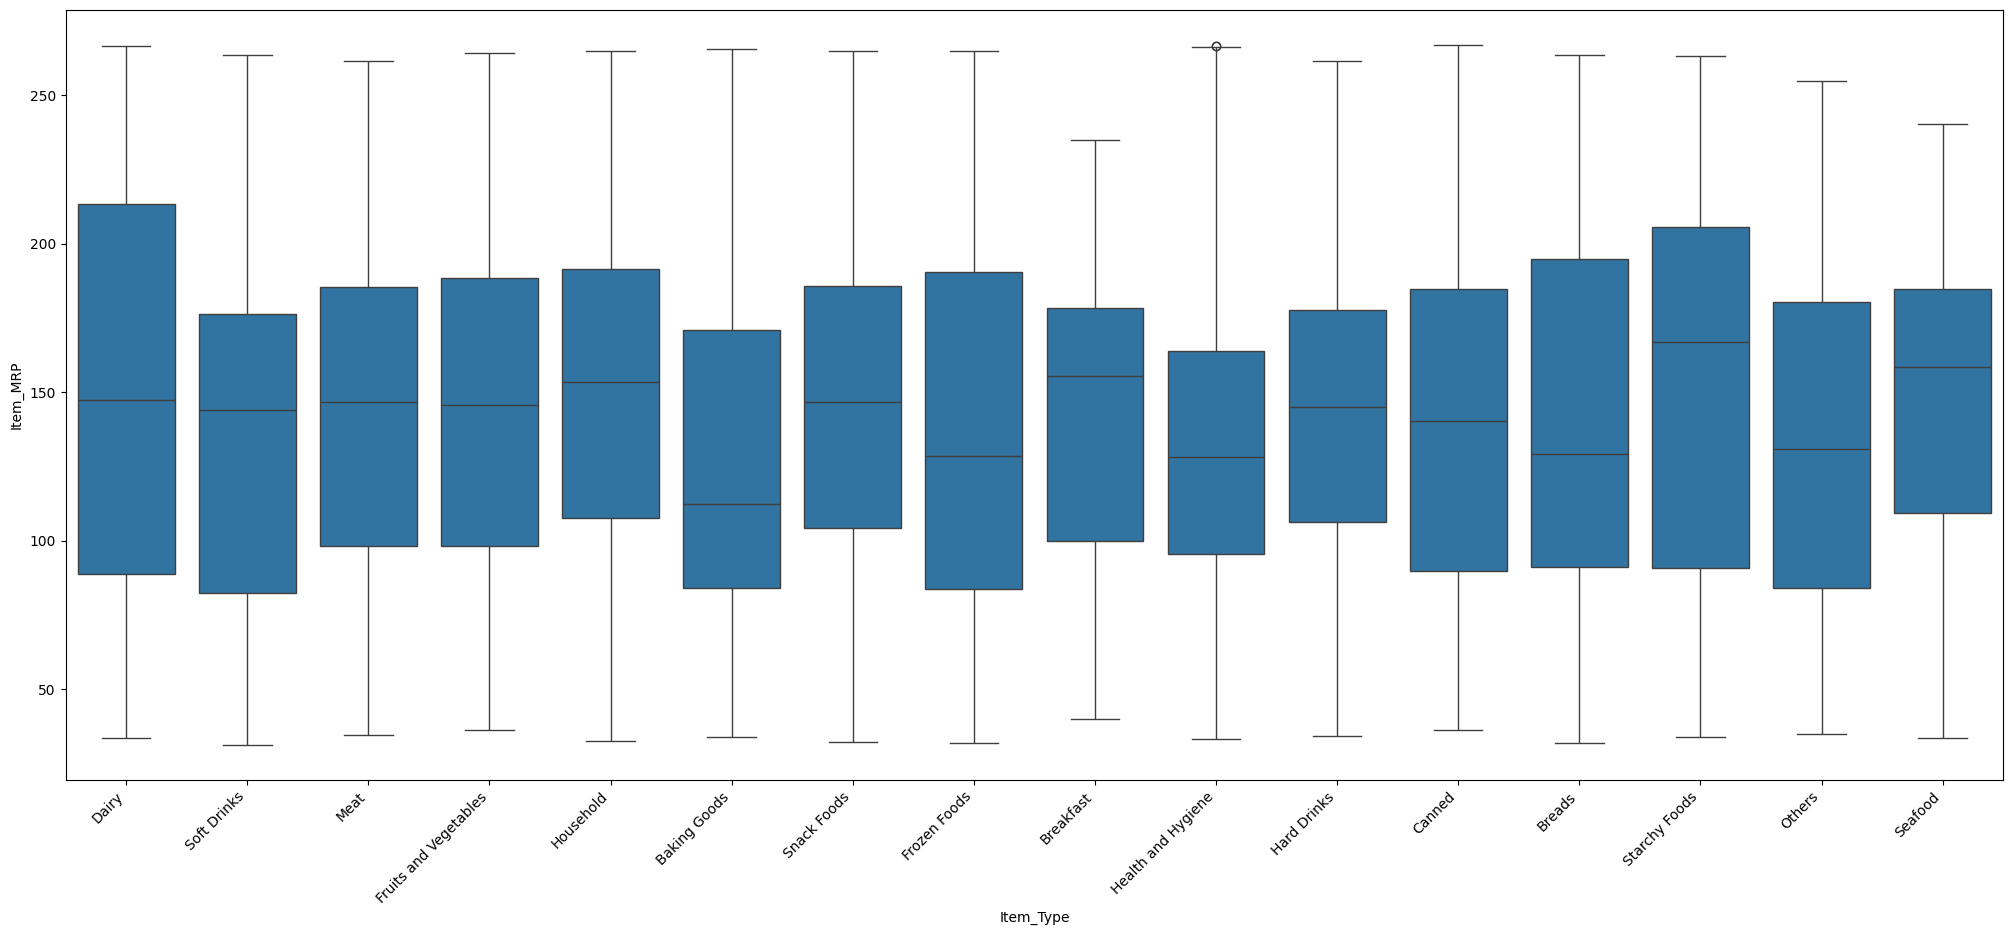

In [16]:
# visualize the Item _MRP boxplot for each product type
fig,ax=plt.subplots(figsize=(25,10))
sns.boxplot(data=df_new,y="Item_MRP",x="Item_Type",ax=ax)
plt.xticks(rotation=45,ha="right")
plt.show()

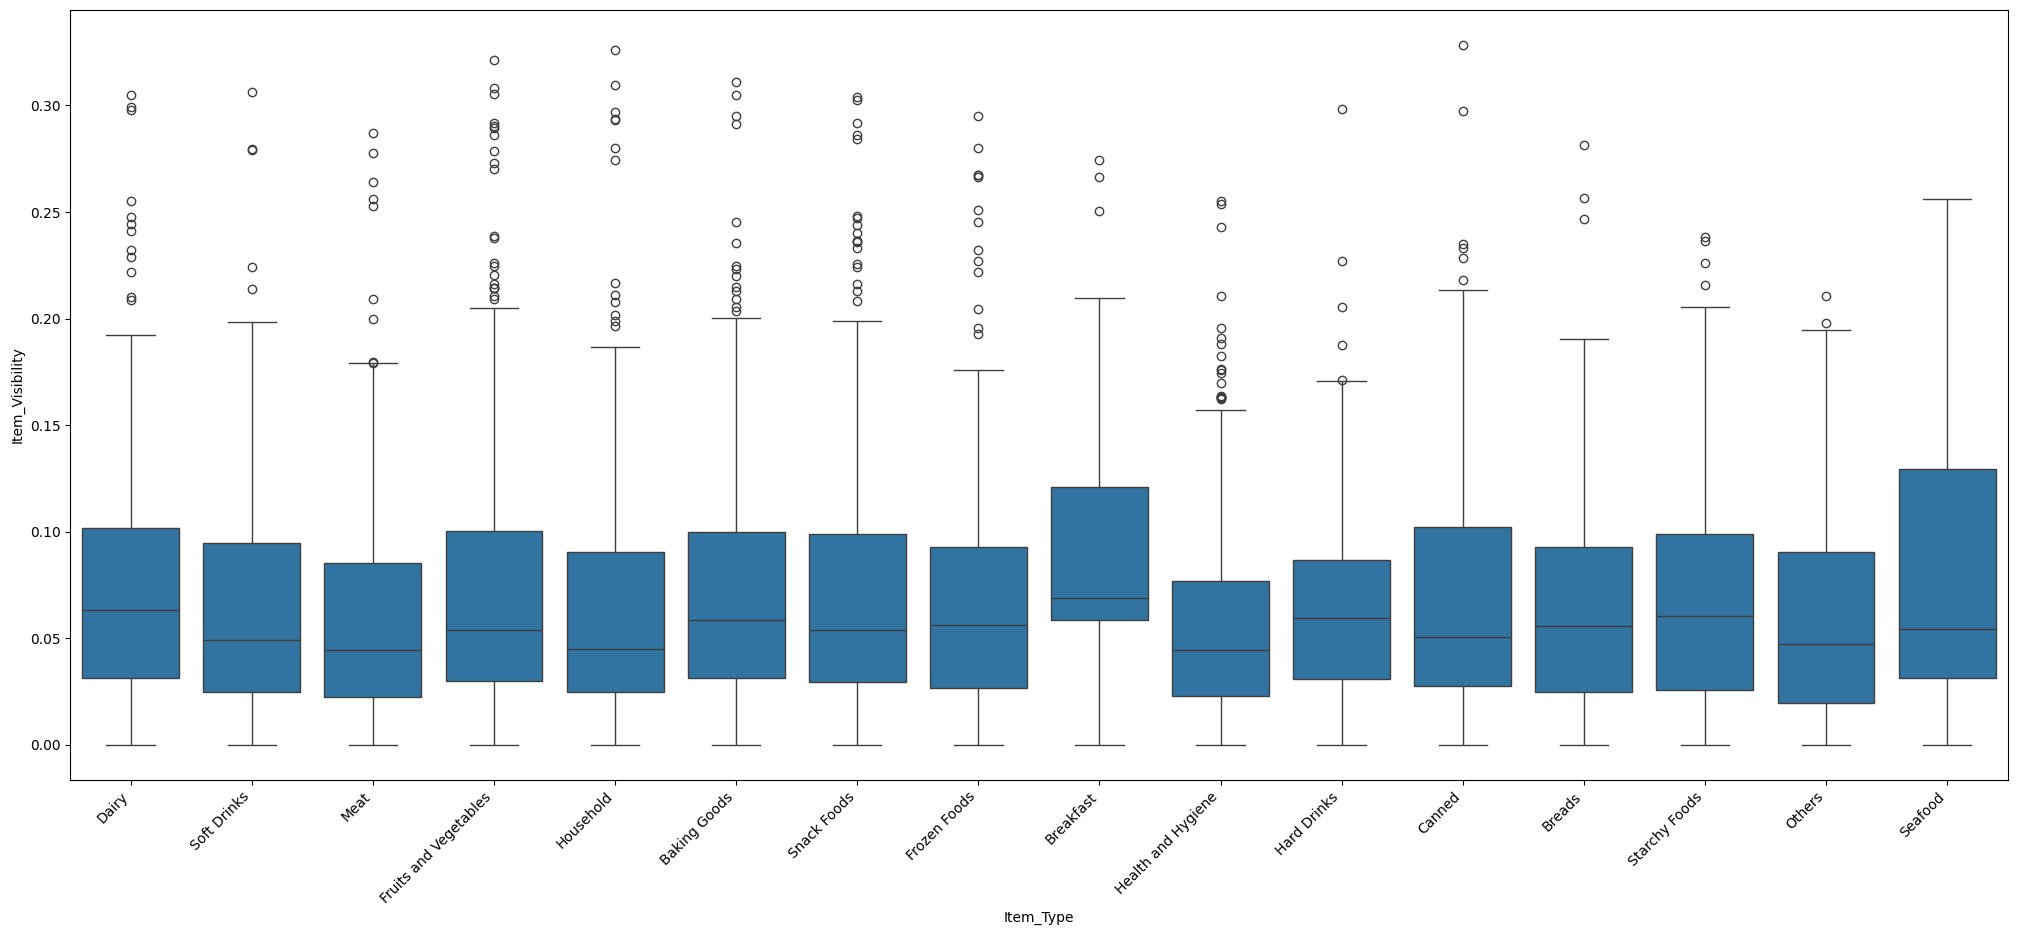

In [17]:
# visualize the Item_Visibility-boxplot for each product type
fig,ax=plt.subplots(figsize=(25,10))
sns.boxplot(data=df_new,y="Item_Visibility",x="Item_Type",ax=ax)
plt.xticks(rotation=45,ha="right")
plt.show()

In [18]:
df_new.Item_Fat_Content.value_counts()

Item_Fat_Content
LF     5201
Reg    3006
Name: count, dtype: int64

### Observation
`Item_Fat_Content` consists of only two categorical values low fat and reg
so we should clean it first

In [19]:
df_new.Item_Fat_Content.value_counts()

Item_Fat_Content
LF     5201
Reg    3006
Name: count, dtype: int64

<Axes: xlabel='Item_Fat_Content', ylabel='Item_MRP'>

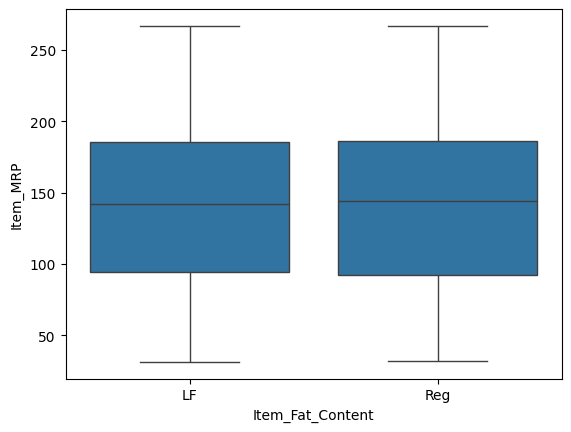

In [20]:
## se how much the fat content afftects the Item_MRP
sns.boxplot(data=df_new,x="Item_Fat_Content",y="Item_MRP")

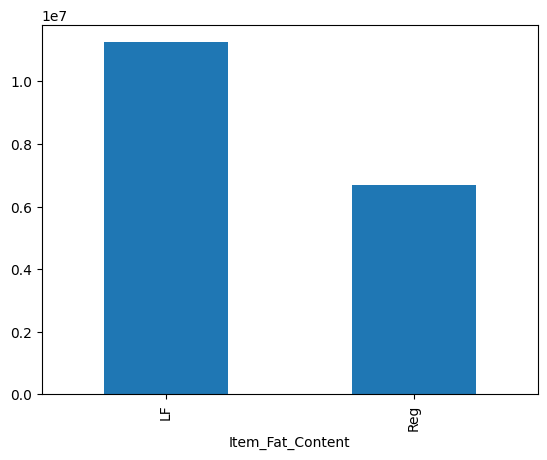

In [21]:
# see How much the Item Fat Content afects  Item_Outlet_Sales
df_new.groupby("Item_Fat_Content").Item_Outlet_Sales.sum().plot(kind="bar")
plt.show()

### Observation
The LF Items was sold the most

In [22]:
Outlet_Identifiers=df_new.Outlet_Identifier.unique()
Outlet_Identifiers

<StringArray>
['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045', 'OUT017',
 'OUT046', 'OUT035', 'OUT019']
Length: 10, dtype: str

In [23]:
# calcutae the total Income for each outlet
df_new.groupby("Outlet_Identifier").Item_Outlet_Sales.sum()

Outlet_Identifier
OUT010    1.883402e+05
OUT013    2.142664e+06
OUT017    2.167465e+06
OUT018    1.851823e+06
OUT019    1.796941e+05
OUT027    3.453926e+06
OUT035    2.268123e+06
OUT045    2.036725e+06
OUT046    2.118395e+06
OUT049    2.183970e+06
Name: Item_Outlet_Sales, dtype: float64

<Axes: >

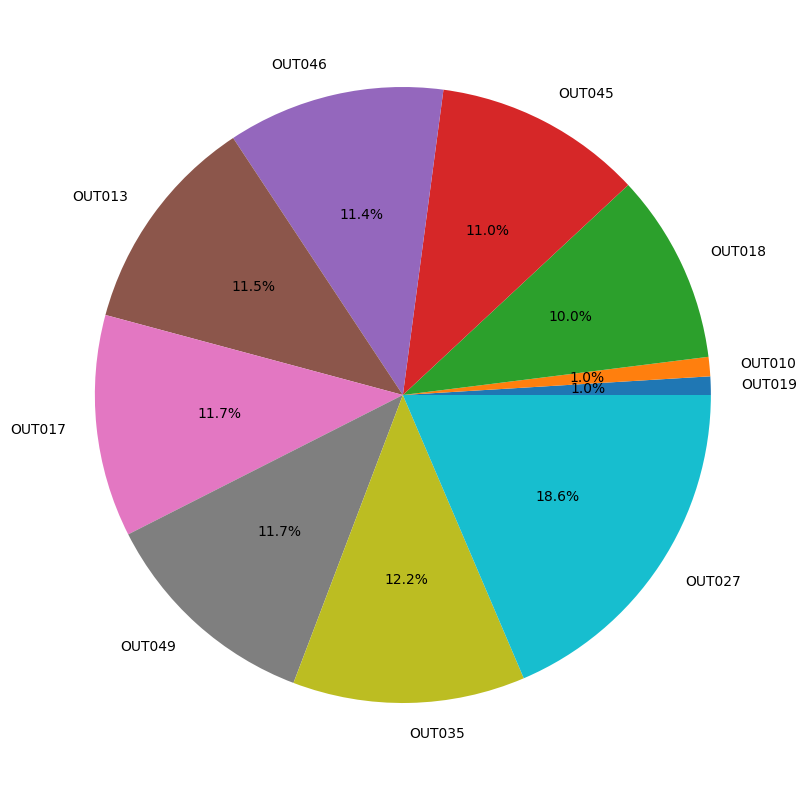

In [24]:
# visualize how much each each outlet contributes in total income
df_new.groupby("Outlet_Identifier").Item_Outlet_Sales.sum().sort_values().plot(kind="pie",autopct="%1.1f%%",figsize=(10,10))

In [25]:
df_new["Item_Quantity_Sold"]

0       15.0
1        9.0
2       15.0
3        4.0
4       18.0
        ... 
8518    13.0
8519     5.0
8520    14.0
8521    18.0
8522    10.0
Name: Item_Quantity_Sold, Length: 8523, dtype: float64

In [26]:
# calc how many products was sold for each outlet
df_new.groupby("Outlet_Identifier").Item_Quantity_Sold.sum()

Outlet_Identifier
OUT010     1323.0
OUT013    14910.0
OUT017    15427.0
OUT018    12859.0
OUT019     1292.0
OUT027    24883.0
OUT035    15779.0
OUT045    14467.0
OUT046    15054.0
OUT049    15472.0
Name: Item_Quantity_Sold, dtype: float64

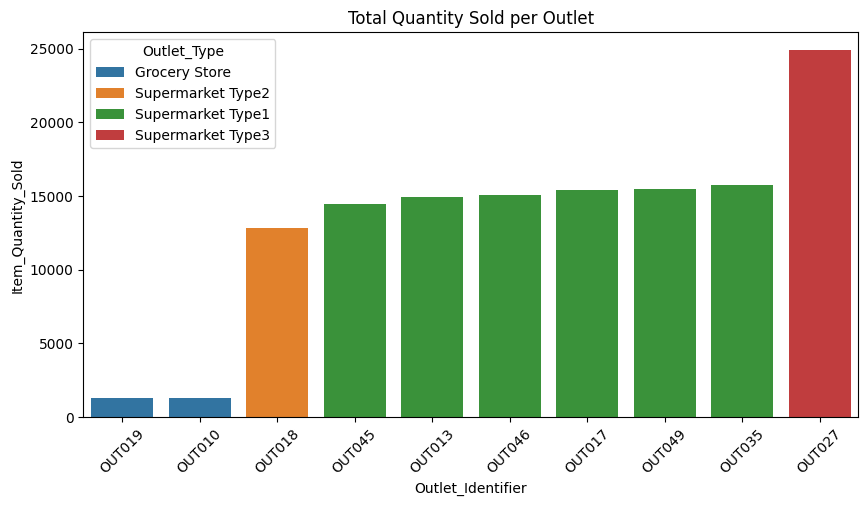

In [27]:
outlet_sales = df_new.groupby(["Outlet_Identifier", "Outlet_Type"])["Item_Quantity_Sold"].sum().reset_index()
outlet_sales = outlet_sales.sort_values(by="Item_Quantity_Sold")
plt.figure(figsize=(10, 5))
sns.barplot(
    data=outlet_sales, 
    x="Outlet_Identifier", 
    y="Item_Quantity_Sold", 
    hue="Outlet_Type", 
    dodge=False  
)

plt.xticks(rotation=45)
plt.title("Total Quantity Sold per Outlet")
plt.show()

In [28]:
df_new["Visibility_Range"]

0         0-5%
1         0-5%
2         0-5%
3          NaN
4          NaN
         ...  
8518     5-10%
8519      0-5%
8520      0-5%
8521    10-15%
8522      0-5%
Name: Visibility_Range, Length: 8523, dtype: category
Categories (7, str): ['0-5%' < '5-10%' < '10-15%' < '15-20%' < '20-25%' < '25-30%' < '+30%']

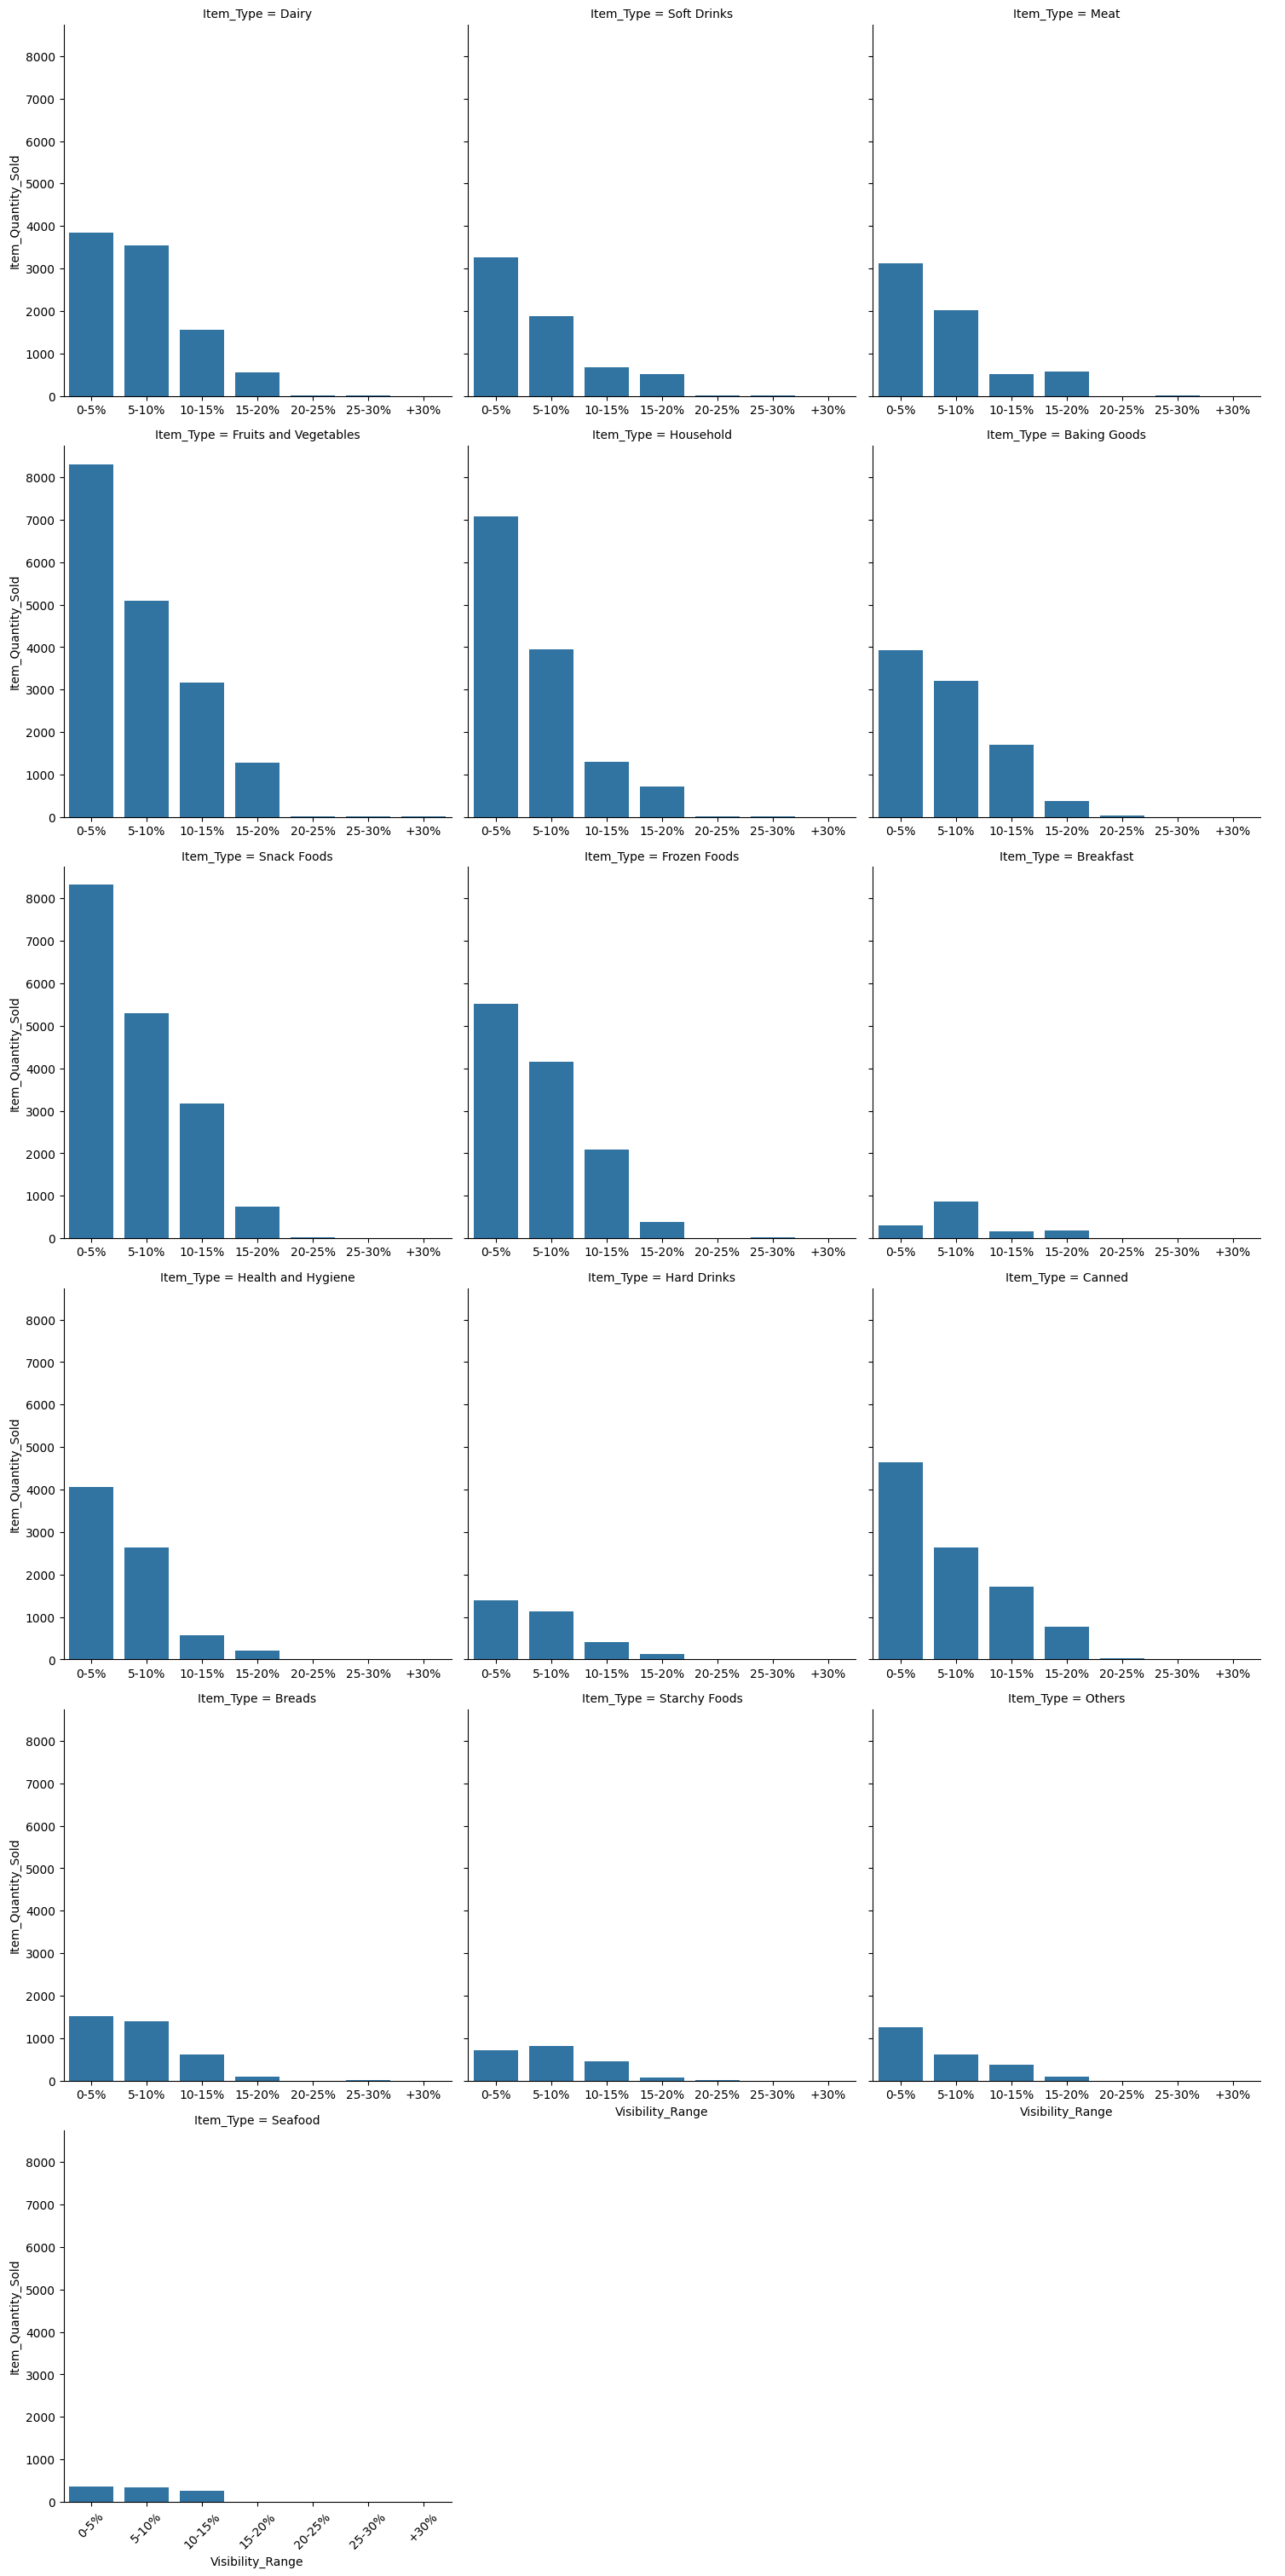

In [29]:
# Visualize how the Visibility_Range afftects the sellling quantity for each product Type
sns.catplot(data=df_new,x="Visibility_Range",y="Item_Quantity_Sold",estimator=sum,kind="bar",col="Item_Type",errorbar=None,col_wrap=3
           ,sharex=False)
plt.xticks(rotation=45)
plt.show()

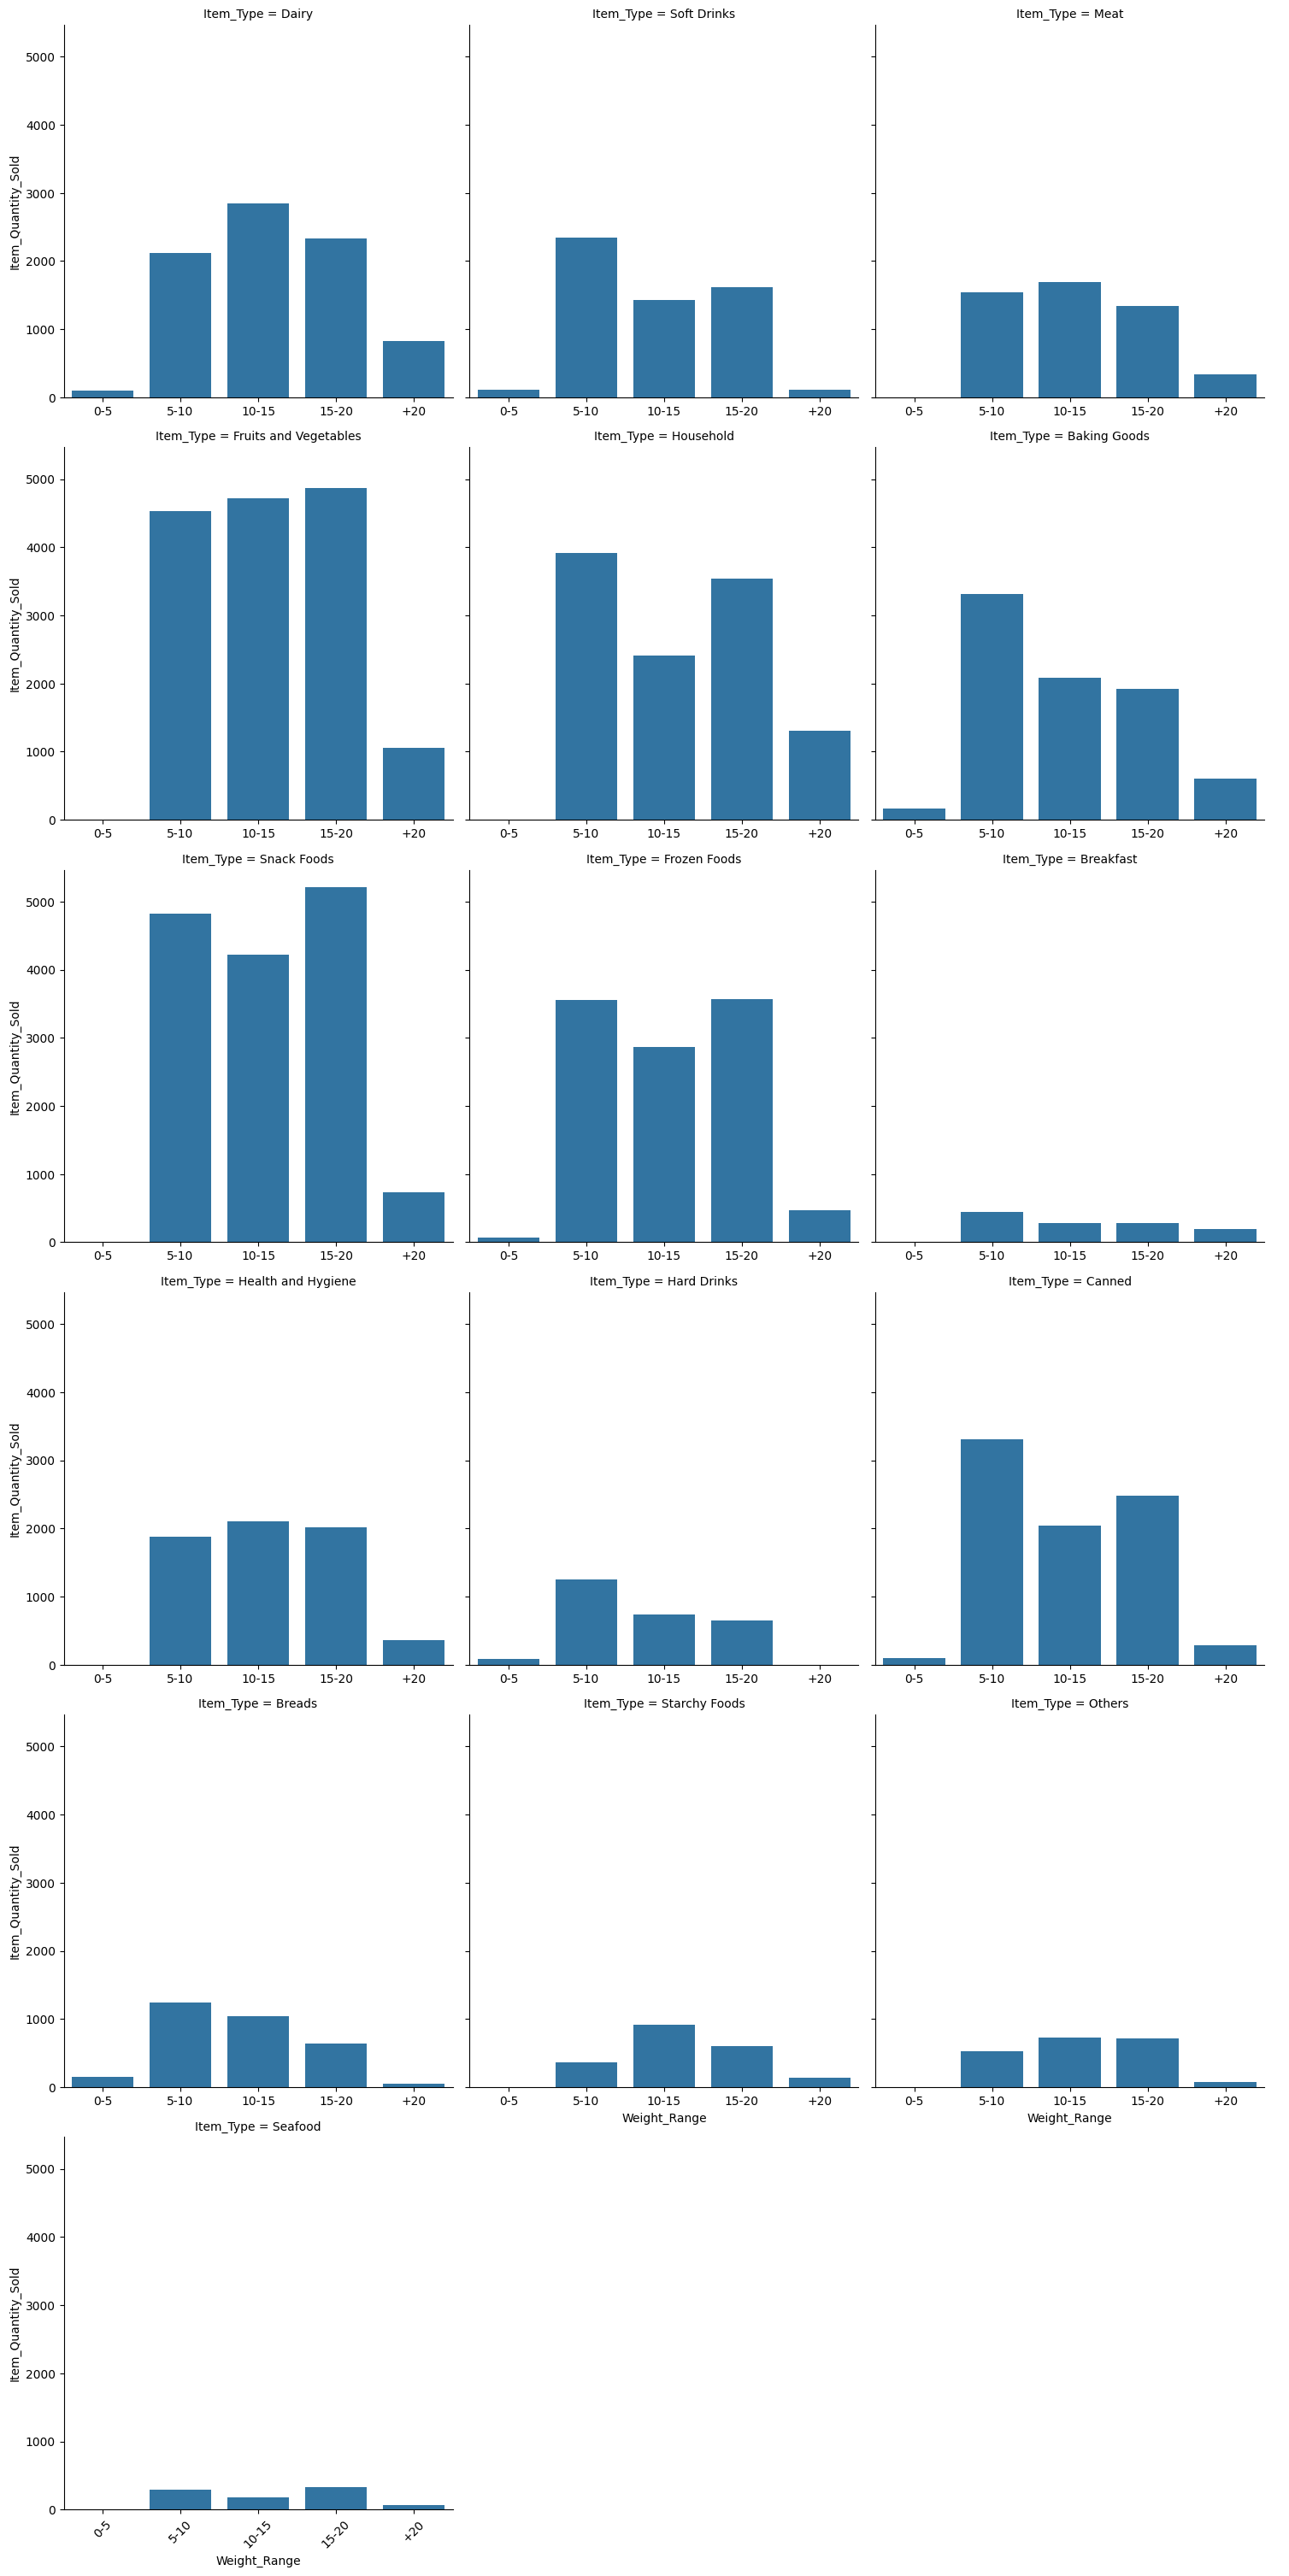

In [30]:
# Visualize how the Visibility_Range afftects the sellling quantity for each product Type
sns.catplot(data=df_new,x="Weight_Range",y="Item_Quantity_Sold",estimator=sum,kind="bar",col="Item_Type",errorbar=None,col_wrap=3,sharex=False)
plt.xticks(rotation=45)
plt.show()

In [31]:
df_new.Outlet_Size.value_counts(dropna=False)

Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64

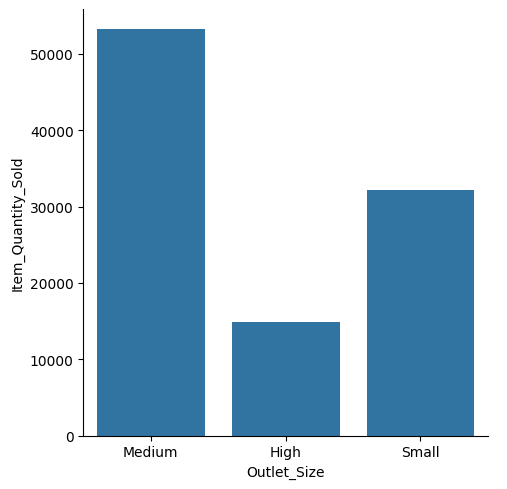

In [32]:
# how much outlet size affects the Item_Quantity_Sold
sns.catplot(data=df_new,x="Outlet_Size",y="Item_Quantity_Sold",estimator=sum,kind="bar",errorbar=None)

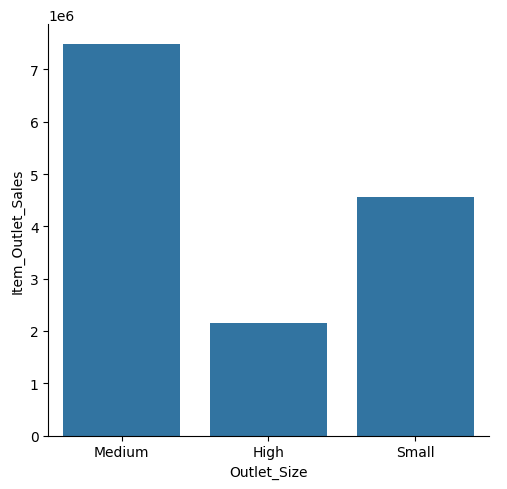

In [33]:
# how much outlet size affects the Item_Outlet_Sales
sns.catplot(data=df_new,x="Outlet_Size",y="Item_Outlet_Sales",estimator=sum,kind="bar",errorbar=None)

In [34]:
df_new.Outlet_Location_Type.value_counts(dropna=False)

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

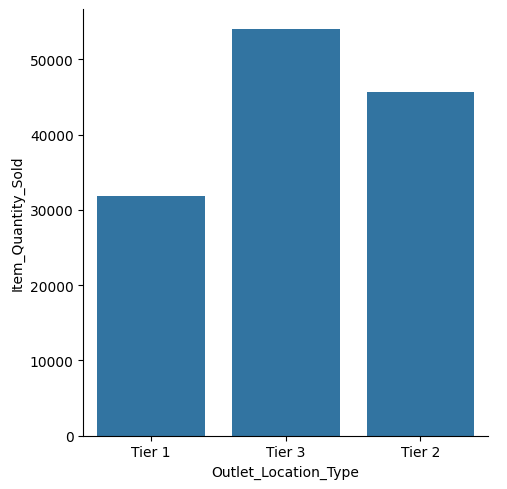

In [35]:
# how much Outlet_Location_Type affects the Item_Quantity_Sold
sns.catplot(data=df_new,x="Outlet_Location_Type",y="Item_Quantity_Sold",estimator=sum,kind="bar",errorbar=None)

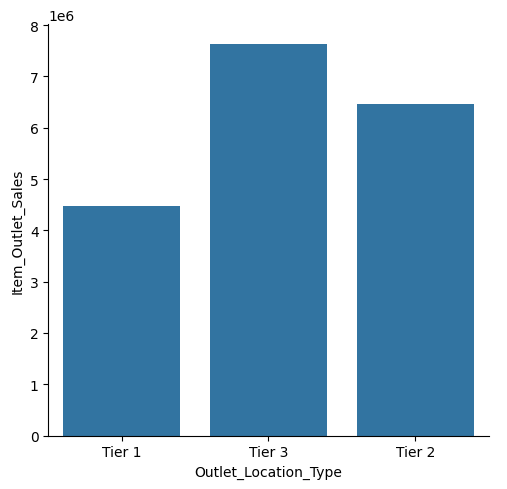

In [36]:
# how much Outlet_Location_Type affects the Item_Outlet_Sales
sns.catplot(data=df_new,x="Outlet_Location_Type",y="Item_Outlet_Sales",estimator=sum,kind="bar",errorbar=None)

In [37]:
df_new.Outlet_Type.value_counts(dropna=False)

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

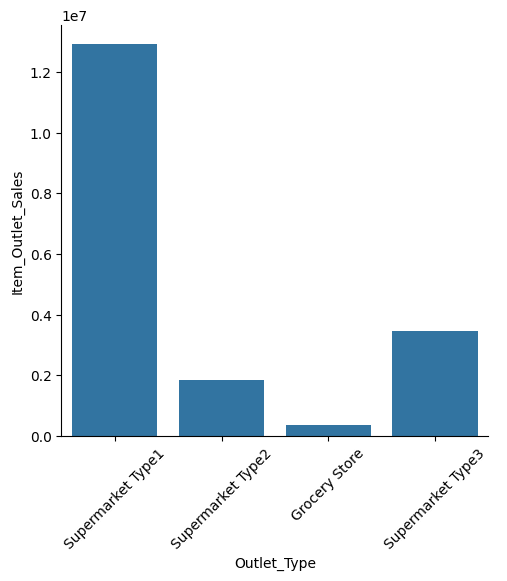

In [38]:
# how much Outlet_Type affects the Item_Outlet_Sales
sns.catplot(data=df_new,x="Outlet_Type",y="Item_Outlet_Sales",estimator=sum,kind="bar",errorbar=None)
plt.xticks(rotation=45)
plt.show()

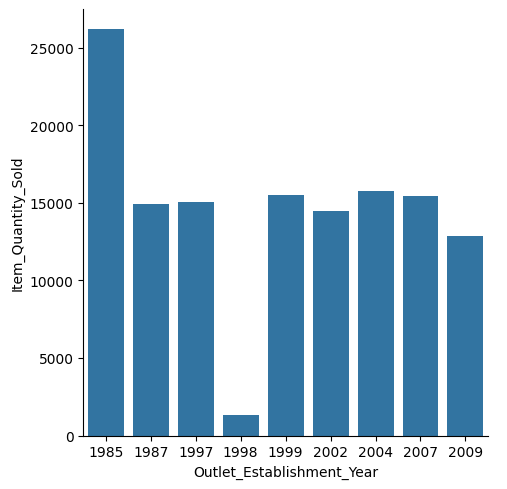

In [39]:
# how much Outlet_Location_Type affects the Item_Quantity_Sold
sns.catplot(data=df_new,x="Outlet_Establishment_Year",y="Item_Quantity_Sold",estimator=sum,kind="bar",errorbar=None)

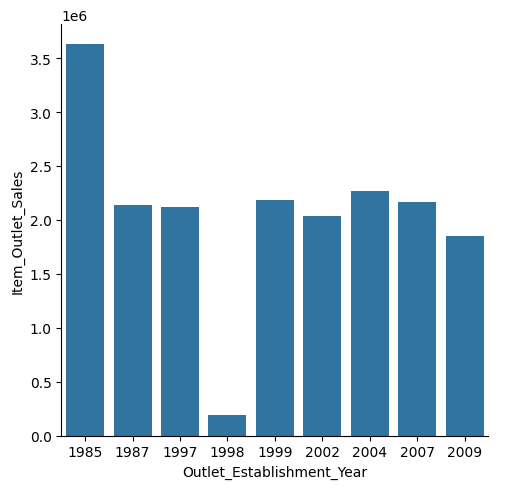

In [40]:
# how much Outlet_Location_Type affects the Item_Outlet_Sales
sns.catplot(data=df_new,x="Outlet_Establishment_Year",y="Item_Outlet_Sales",estimator=sum,kind="bar",errorbar=None)

### Observartion
The Oldest Outlets `s income are very high by far

## Data Preprocessing & Feature Engineering

In [41]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [42]:
def Preprocess_Data(df_Reseved):
    df=df_Reseved.drop("Item_Identifier",axis=1).copy()
    df["Item_Weight"]=df["Item_Weight"].fillna(df["Item_Weight"].median())
    df["Item_Fat_Content"]=df["Item_Fat_Content"].map({"Low Fat":"LF","Regular":"Reg","LF":"LF","reg":"Reg","low fat":"LF"})
    df["Outlet_Size"] = (
    df.groupby(["Outlet_Type", "Outlet_Location_Type"])["Outlet_Size"]
      .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Medium"))
    )
    df["Price_Per_Weight"]=df["Item_MRP"]/df["Item_Weight"]
    df["Item_Fat_Content"]=df["Item_Fat_Content"].map({"LF":0,"Reg":1})
    df["Outlet_Size"]=df["Outlet_Size"].map({"Small":0,"Medium":1,"High":2})
    return df
 

In [43]:
df_Processed=Preprocess_Data(df)

In [44]:
df_Processed

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Price_Per_Weight
0,9.300,0,0.016047,Dairy,249.8092,OUT049,1999,1,Tier 1,Supermarket Type1,3735.1380,26.861204
1,5.920,1,0.019278,Soft Drinks,48.2692,OUT018,2009,1,Tier 3,Supermarket Type2,443.4228,8.153581
2,17.500,0,0.016760,Meat,141.6180,OUT049,1999,1,Tier 1,Supermarket Type1,2097.2700,8.092457
3,19.200,1,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,1,Tier 3,Grocery Store,732.3800,9.484115
4,8.930,0,0.000000,Household,53.8614,OUT013,1987,2,Tier 3,Supermarket Type1,994.7052,6.031512
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,Snack Foods,214.5218,OUT013,1987,2,Tier 3,Supermarket Type1,2778.3834,31.248623
8519,8.380,1,0.046982,Baking Goods,108.1570,OUT045,2002,0,Tier 2,Supermarket Type1,549.2850,12.906563
8520,10.600,0,0.035186,Health and Hygiene,85.1224,OUT035,2004,0,Tier 2,Supermarket Type1,1193.1136,8.030415
8521,7.210,1,0.145221,Snack Foods,103.1332,OUT018,2009,1,Tier 3,Supermarket Type2,1845.5976,14.304189


<Axes: >

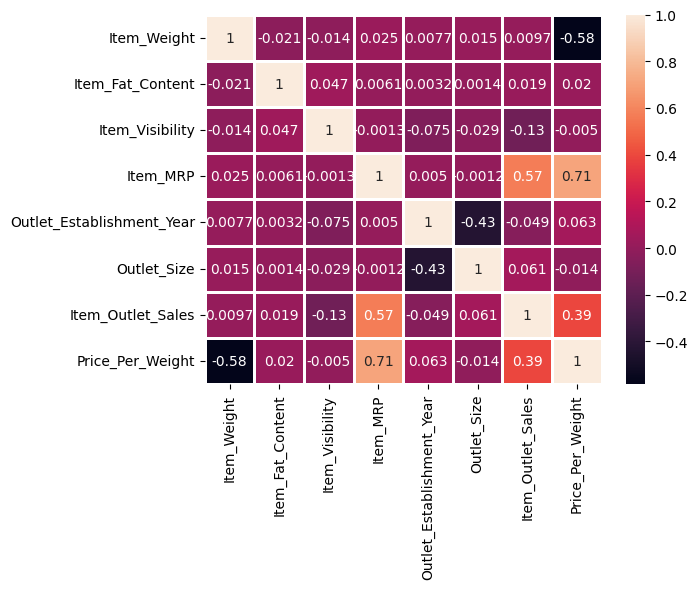

In [45]:
sns.heatmap(df_Processed.corr(numeric_only=True),annot=True,linewidth=2)

In [46]:
Cat_cols=["Item_Type","Outlet_Identifier","Outlet_Location_Type","Outlet_Type"]
Num_cols=["Item_Weight","Item_Visibility","Item_MRP","Price_Per_Weight","Outlet_Establishment_Year"]

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(transformers=[
    ("Standard_Scaler",StandardScaler(),Num_cols)
    ,("OneHotEncoder",OneHotEncoder(sparse_output=False),Cat_cols)
],remainder="passthrough")



## Splitting Data

In [47]:
df_Processed.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Price_Per_Weight'],
      dtype='str')

In [48]:
x=df_Processed.drop(["Item_Outlet_Sales"],axis=1)
y=df_Processed["Item_Outlet_Sales"]

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_tmp,y_train,y_tmp=train_test_split(x,y,test_size=0.3,shuffle=True
                                             ,stratify=x.Outlet_Identifier)
x_val,x_test,y_val,y_test=train_test_split(x_tmp,y_tmp,test_size=0.5,shuffle=True
                                             ,stratify=x_tmp.Outlet_Identifier)
print(f"x Train Shape:{x_train.shape}")
print(f"y Train Shape:{y_train.shape}")
print(f"x Val Shape:{x_val.shape}")
print(f"y Val Shape:{y_val.shape}")
print(f"x test Shape:{x_test.shape}")
print(f"y test Shape:{y_test.shape}")

x Train Shape:(5966, 11)
y Train Shape:(5966,)
x Val Shape:(1278, 11)
y Val Shape:(1278,)
x test Shape:(1279, 11)
y test Shape:(1279,)


In [50]:
x_train_transformed=pd.DataFrame(transformer.fit_transform(x_train),columns=transformer.get_feature_names_out())
x_val_transformed=pd.DataFrame(transformer.transform(x_val),columns=transformer.get_feature_names_out())
x_test_transformed=pd.DataFrame(transformer.transform(x_test),columns=transformer.get_feature_names_out())
print(f"x Train transformed Shape:{x_train_transformed.shape}")
print(f"x Val transformed Shape:{x_val_transformed.shape}")
print(f"x test transformed Shape:{x_test_transformed.shape}")

x Train transformed Shape:(5966, 40)
x Val transformed Shape:(1278, 40)
x test transformed Shape:(1279, 40)


In [51]:
x_train_transformed

,Standard_Scaler__Item_Weight,Standard_Scaler__Item_Visibility,Standard_Scaler__Item_MRP,Standard_Scaler__Price_Per_Weight,Standard_Scaler__Outlet_Establishment_Year,OneHotEncoder__Item_Type_Baking Goods,OneHotEncoder__Item_Type_Breads,OneHotEncoder__Item_Type_Breakfast,OneHotEncoder__Item_Type_Canned,OneHotEncoder__Item_Type_Dairy,...,OneHotEncoder__Outlet_Identifier_OUT049,OneHotEncoder__Outlet_Location_Type_Tier 1,OneHotEncoder__Outlet_Location_Type_Tier 2,OneHotEncoder__Outlet_Location_Type_Tier 3,OneHotEncoder__Outlet_Type_Grocery Store,OneHotEncoder__Outlet_Type_Supermarket Type1,OneHotEncoder__Outlet_Type_Supermarket Type2,OneHotEncoder__Outlet_Type_Supermarket Type3,remainder__Item_Fat_Content,remainder__Outlet_Size
0,0.316006,1.159342,-0.842084,-0.822696,1.334006,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.167204,-1.046477,0.419551,-0.404388,0.736705,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.445502,0.410060,-0.194630,0.914633,0.736705,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.446050,2.031029,-1.457407,-1.200443,-1.294120,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0
4,-0.818925,0.879267,-1.227153,-0.733793,1.095086,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5961,-0.914685,-0.533216,1.094903,1.461440,-1.294120,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
5962,-1.731599,-0.795966,1.613282,4.227739,-1.294120,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0
5963,-0.859121,-0.282692,0.167876,0.543688,0.139404,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5964,1.167204,1.327864,0.700182,-0.273613,-1.294120,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0


In [52]:
x_val_transformed

,Standard_Scaler__Item_Weight,Standard_Scaler__Item_Visibility,Standard_Scaler__Item_MRP,Standard_Scaler__Price_Per_Weight,Standard_Scaler__Outlet_Establishment_Year,OneHotEncoder__Item_Type_Baking Goods,OneHotEncoder__Item_Type_Breads,OneHotEncoder__Item_Type_Breakfast,OneHotEncoder__Item_Type_Canned,OneHotEncoder__Item_Type_Dairy,...,OneHotEncoder__Outlet_Identifier_OUT049,OneHotEncoder__Outlet_Location_Type_Tier 1,OneHotEncoder__Outlet_Location_Type_Tier 2,OneHotEncoder__Outlet_Location_Type_Tier 3,OneHotEncoder__Outlet_Type_Grocery Store,OneHotEncoder__Outlet_Type_Supermarket Type1,OneHotEncoder__Outlet_Type_Supermarket Type2,OneHotEncoder__Outlet_Type_Supermarket Type3,remainder__Item_Fat_Content,remainder__Outlet_Size
0,1.888358,-0.821745,-0.270153,-0.862615,-1.294120,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0
1,-0.038660,-0.483806,-0.587700,-0.556891,-1.533040,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.038660,-1.008037,-1.459608,-1.127661,-1.533040,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.788894,-0.805940,-0.732354,-0.870075,0.736705,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.942583,-0.657865,0.822823,-0.134781,0.736705,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,1.876536,1.066802,-0.368706,-0.899967,-0.099517,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1274,-1.749332,1.429284,0.527798,2.641162,0.736705,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1275,-0.038660,0.395568,-0.999016,-0.826147,-1.533040,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1276,1.060805,-0.367906,-0.708774,-0.911238,1.095086,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [53]:
x_test_transformed

,Standard_Scaler__Item_Weight,Standard_Scaler__Item_Visibility,Standard_Scaler__Item_MRP,Standard_Scaler__Price_Per_Weight,Standard_Scaler__Outlet_Establishment_Year,OneHotEncoder__Item_Type_Baking Goods,OneHotEncoder__Item_Type_Breads,OneHotEncoder__Item_Type_Breakfast,OneHotEncoder__Item_Type_Canned,OneHotEncoder__Item_Type_Dairy,...,OneHotEncoder__Outlet_Identifier_OUT049,OneHotEncoder__Outlet_Location_Type_Tier 1,OneHotEncoder__Outlet_Location_Type_Tier 2,OneHotEncoder__Outlet_Location_Type_Tier 3,OneHotEncoder__Outlet_Type_Grocery Store,OneHotEncoder__Outlet_Type_Supermarket Type1,OneHotEncoder__Outlet_Type_Supermarket Type2,OneHotEncoder__Outlet_Type_Supermarket Type3,remainder__Item_Fat_Content,remainder__Outlet_Size
0,-0.038660,0.643315,-0.538974,-0.524994,-1.533040,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.038660,-0.606309,1.458001,0.782267,-1.533040,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.906409,-1.032633,-1.359404,-0.817710,1.095086,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.316006,-1.289644,1.463885,0.526251,0.139404,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.843752,-0.046396,-0.875274,-0.407607,0.139404,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274,0.457872,-0.884312,0.057045,-0.352229,-1.294120,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0
1275,0.930760,-0.271733,-0.435128,-0.751533,0.139404,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1276,-1.388755,-1.289644,0.844795,2.069393,0.139404,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1277,-0.582481,-1.072670,-0.873707,-0.540351,1.095086,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Training a Ml Model

In [54]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
models=[("ridge",Ridge(random_state=42)),
        ("svr_linear",SVR(kernel="linear")),
        ("svr_rbf",SVR(kernel="rbf")),
       ("Random_Forest",RandomForestRegressor(random_state=42)),
       ("XGBRegressor",XGBRegressor(random_state=42))]

In [55]:
from sklearn.metrics import root_mean_squared_error
def Evaluate_Models(models,x_train,y_train,x_val=None,y_val=None,x_test=None,y_test=None):
    Results={}
    for model_info in models:
        model_name=model_info[0]
        model=model_info[1]
        model.fit(x_train,y_train)
        training_predictions=model.predict(x_train)
        trainingset_result=root_mean_squared_error(y_train,training_predictions)
        Results[model_name]=[("Trainging",trainingset_result)]
        if x_val is not None:
            val_predictions=model.predict(x_val)
            Validationset_result=root_mean_squared_error(y_val,val_predictions)
            Results[model_name].append(("Valdiation",Validationset_result))
        if x_test is not None:
            test_predictions=model.predict(x_test)
            testset_result=root_mean_squared_error(y_test,test_predictions)
            Results[model_name].append(("Test",testset_result))
    return Results   
        
        
    

In [56]:
Results=Evaluate_Models(models,x_train=x_train_transformed,y_train=y_train)

In [57]:
def Dispaly_Results(Results):
    for key,value in Results.items():
        print("------------------------------------------")
        print(f"Model Name :{key}")
        for Result in value:
            print(f"{Result[0]} score : {Result[1]}")
       

In [58]:
# Displaying The Traning Set Results
Dispaly_Results(Results)

------------------------------------------
Model Name :ridge
Trainging score : 1134.9252172247304
------------------------------------------
Model Name :svr_linear
Trainging score : 1268.7032241222232
------------------------------------------
Model Name :svr_rbf
Trainging score : 1672.308794635372
------------------------------------------
Model Name :Random_Forest
Trainging score : 428.3687546810974
------------------------------------------
Model Name :XGBRegressor
Trainging score : 577.8194953026557


# Displaying The Traning & avldiation  Sets Results
Results=Evaluate_Models(models,x_train=x_train_transformed,y_train=y_train
                        ,x_val=x_val_transformed,y_val=y_val)
Dispaly_Results(Results)

> ### The Random Forest and XGBRegressor tends to overfit

## Hyperparameter Tuning

In [59]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [60]:
from sklearn.model_selection  import KFold
cv_splits = KFold(n_splits=3, shuffle=True, random_state=42)

In [61]:
Ridge_params={"alpha":[0.001,0.01,0.1,1.0,10,23,24,25],
"fit_intercept":[True,False],
"solver":['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            "max_iter":[1000,5000,10000,15000,20000]
}
Ridge_GridSearchCV=GridSearchCV(Ridge(random_state=42),Ridge_params,
             cv=cv_splits,n_jobs=-1,scoring="neg_root_mean_squared_error")
Ridge_GridSearchCV.fit(x_train_transformed,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'fit_intercept': [True, False], 'max_iter': [1000, 5000, ...], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [62]:
Ridge_GridSearchCV.best_params_

{'alpha': 24, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'sparse_cg'}

In [63]:
ridge=Ridge(random_state=42,alpha= 24, fit_intercept= True, max_iter= 1000, solver='sparse_cg')

In [64]:
SVR_rbf_Params={'kernel': ['rbf'],
    'C': [ 10,100,200,300,400,500,1000],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.0001,0.0005,0.001,0.01, 0.1]
}
SVR_rbf_GridSearchCV=GridSearchCV(SVR(),SVR_rbf_Params,
             cv=cv_splits,n_jobs=-1,scoring="neg_root_mean_squared_error")
SVR_rbf_GridSearchCV.fit(x_train_transformed,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [10, 100, ...], 'epsilon': [0.0001, 0.0005, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [65]:
SVR_rbf_GridSearchCV.best_params_

{'C': 500, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

In [66]:
SVR_rbf=SVR(kernel="rbf",C=500,gamma=0.1,epsilon=0.1)

In [67]:
SVR_linear_Params={
    'kernel': ['linear'],
    'C':[0.01, 0.1, 1, 10, 100,200,300,400],
    'epsilon': [0, 0.01,0.01,0.001, 0.1, 0.2,1],
    'max_iter': [ 50000,100000]
}
SVR_linear_GridSearchCV=GridSearchCV(SVR(),SVR_linear_Params,
             cv=cv_splits,n_jobs=-1,scoring="neg_root_mean_squared_error")
SVR_linear_GridSearchCV.fit(x_train_transformed,y_train)


C:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'epsilon': [0, 0.01, ...], 'kernel': ['linear'], 'max_iter': [50000, 100000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [68]:
SVR_linear_GridSearchCV.best_params_

{'C': 400, 'epsilon': 0.01, 'kernel': 'linear', 'max_iter': 50000}

In [69]:
SVR_linear=SVR(kernel="linear",C=400,epsilon=0.01,max_iter=100000)

In [70]:
param_grid = {
    "n_estimators": [100,200,300,400, 500],
    "max_depth": [ 10, 20, 30,40],
    "min_samples_split": [ 10,15,20],
    "min_samples_leaf": [ 2, 4,6,8],
    "max_features": [0.25, "sqrt", 0.5]
}
Random_Forest_RandomizedSearchCV=RandomizedSearchCV(RandomForestRegressor(random_state=42),param_grid,
             cv=cv_splits,n_jobs=-1,scoring="neg_root_mean_squared_error",n_iter=200)
Random_Forest_RandomizedSearchCV.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': [0.25, 'sqrt', ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [10, 15, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [71]:
Random_Forest_RandomizedSearchCV.best_params_

{'n_estimators': 300,
 'min_samples_split': 15,
 'min_samples_leaf': 8,
 'max_features': 0.25,
 'max_depth': 10}

In [75]:
Random_Forest_Reg=RandomForestRegressor(random_state=42,n_estimators= 300,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features=0.25)


In [76]:
param_grid = {
    "n_estimators": [200,250,300,400,100,150],
    "learning_rate": [0.005,0.01,0.03, 0.05, 0.1],
    "max_depth": [2,3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.4,0.6,0.8, 1.0],
    "colsample_bytree": [0.1,0.4,0.8, 1.0]
}
XGB_RandomizedSearchCV=RandomizedSearchCV(XGBRegressor(random_state=42),param_grid,
             cv=cv_splits,n_jobs=-1,scoring="neg_root_mean_squared_error",n_iter=500)
XGB_RandomizedSearchCV.fit(x_train_transformed,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.1, 0.4, ...], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [77]:
XGB_RandomizedSearchCV.best_params_

{'subsample': 1.0,
 'n_estimators': 150,
 'min_child_weight': 3,
 'max_depth': 2,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [81]:
XGB_Regressor=XGBRegressor(random_state=42,n_estimators= 150,
    max_depth=2,
    min_child_weight=3,
    subsample=1.0,
   colsample_bytree=1,
      learning_rate=0.05 )

In [82]:
Models=[("Ridge",ridge),("SVR_rbf",SVR_rbf),
        ("SVR_linear",SVR_linear),("XGB_Regressor",XGB_Regressor)
        ,("Random_Forest_Reg",Random_Forest_Reg)]

In [85]:
Results=Evaluate_Models(Models,x_train_transformed,y_train,x_val_transformed,y_val)

C:\Users\Administrator\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [86]:
# Displaying The Traning Set Results and Valdiation set
Dispaly_Results(Results)

------------------------------------------
Model Name :Ridge
Trainging score : 1135.083510395562
Valdiation score : 1105.5167879502299
------------------------------------------
Model Name :SVR_rbf
Trainging score : 1056.9871733434425
Valdiation score : 1075.3617538937203
------------------------------------------
Model Name :SVR_linear
Trainging score : 1148.289357270108
Valdiation score : 1103.6098605194425
------------------------------------------
Model Name :XGB_Regressor
Trainging score : 1070.402423384961
Valdiation score : 1053.5192319498758
------------------------------------------
Model Name :Random_Forest_Reg
Trainging score : 1012.9997022693543
Valdiation score : 1062.2634720511414


> ###  SVR_rbf, Random_Forest_Reg ,XGB_Regressor are The Most Powerfull ones

In [89]:
Models=[("SVR_rbf",SVR_rbf)
        ,("XGB_Regressor",XGB_Regressor)
        ,("Random_Forest_Reg",Random_Forest_Reg)]

In [90]:
Results=Evaluate_Models(Models,x_train_transformed,y_train,x_val_transformed,y_val,x_test_transformed,y_test)

In [91]:
# Displaying The Traning Set Results and Valdiation set and Test Set
Dispaly_Results(Results)

------------------------------------------
Model Name :SVR_rbf
Trainging score : 1056.9871733434425
Valdiation score : 1075.3617538937203
Test score : 1081.526481995884
------------------------------------------
Model Name :XGB_Regressor
Trainging score : 1070.402423384961
Valdiation score : 1053.5192319498758
Test score : 1058.4227486292461
------------------------------------------
Model Name :Random_Forest_Reg
Trainging score : 1012.9997022693543
Valdiation score : 1062.2634720511414
Test score : 1063.8802431218653


In [94]:
from sklearn.ensemble import VotingRegressor
voting_regressor=VotingRegressor(estimators=[("SVR_rbf",SVR_rbf)
        ,("XGB_Regressor",XGB_Regressor)
        ,("Random_Forest_Reg",Random_Forest_Reg)])

In [95]:
Models=[("SVR_rbf",SVR_rbf)
        ,("XGB_Regressor",XGB_Regressor)
        ,("Random_Forest_Reg",Random_Forest_Reg),
       ("Voting Regressor",voting_regressor)]

In [97]:
Results=Evaluate_Models(Models,x_train_transformed,y_train,x_val_transformed,y_val,x_test_transformed,y_test)

In [98]:
# Displaying The Traning Set Results and Valdiation set and Test Set
Dispaly_Results(Results)

------------------------------------------
Model Name :SVR_rbf
Trainging score : 1056.9871733434425
Valdiation score : 1075.3617538937203
Test score : 1081.526481995884
------------------------------------------
Model Name :XGB_Regressor
Trainging score : 1070.402423384961
Valdiation score : 1053.5192319498758
Test score : 1058.4227486292461
------------------------------------------
Model Name :Random_Forest_Reg
Trainging score : 1012.9997022693543
Valdiation score : 1062.2634720511414
Test score : 1063.8802431218653
------------------------------------------
Model Name :Voting Regressor
Trainging score : 1040.9730718151561
Valdiation score : 1057.4770313344566
Test score : 1061.8556256265085


> ### XGBoost achieved the best performance with a test RMSE of approximately 1058.42.